In [1]:
import numpy as np
import pandas as pd

In [2]:
labeled=pd.read_csv("encodeing_label.csv")

In [3]:
labeled.head(5)

,label
0,Bipolar
1,Suicidal
2,Personality_disorder
3,Anxiety
4,Anxiety


In [12]:

temp_data = np.load('embeddingsbert_embeddings.npy', allow_pickle=True)
print(temp_data.shape)


(26298, 384)


In [13]:

embeddings_data = np.load('embeddingsbert_embeddings.npy')


In [14]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
y = le.fit_transform(labeled['label'])


print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Anxiety': np.int64(0), 'Bipolar': np.int64(1), 'Depression': np.int64(2), 'Normal': np.int64(3), 'Personality_disorder': np.int64(4), 'Stress': np.int64(5), 'Suicidal': np.int64(6)}


In [15]:
labeled.describe()

,label
count,26298
unique,7
top,Suicidal
freq,5588


In [16]:
labeled.value_counts()

,count
label,
Suicidal,5588
Anxiety,4704
Normal,4574
Depression,4111
Personality_disorder,2807
Bipolar,2720
Stress,1794


In [17]:

y = le.transform(labeled['label'])


In [18]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(embeddings_data, y, test_size=0.2, random_state=42, stratify=y)

print(f"size of train data{X_train.shape}")
print(f"size of test data {X_test.shape}")


size of train data(21038, 384)
size of test data (5260, 384)


In [19]:
print(embeddings_data.shape)


(26298, 384)


In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
import numpy as np
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

model = Sequential([
    Dense(1024, input_shape=(384,)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/150
658/658 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.5732 - loss: 1.3036 - val_accuracy: 0.7152 - val_loss: 0.8158 - learning_rate: 5.0000e-04
Epoch 2/150
658/658 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6804 - loss: 0.9084 - val_accuracy: 0.7471 - val_loss: 0.7376 - learning_rate: 5.0000e-04
Epoch 3/150
658/658 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7099 - loss: 0.8350 - val_accuracy: 0.7542 - val_loss: 0.7027 - learning_rate: 5.0000e-04
Epoch 4/150
658/658 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7225 - loss: 0.8018 - val_accuracy: 0.7557 - val_loss: 0.6914 - learning_rate: 5.0000e-04
Epoch 5/150
658/658 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7336 - loss: 0.7725 - val_accuracy: 0.7624 - val_loss: 0.6703 - learning_rate: 5.0000e-04
Epoch 6/150
658/658 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7367 - loss: 0.7567 - val_accuracy: 0.7510 - val_loss: 0.6833 - learning_rate: 5.0000e-04
Epoch 7/150
658/658 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - a

165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Detailed Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.83      0.82      0.82       941
             Bipolar       0.77      0.75      0.76       544
          Depression       0.59      0.62      0.60       822
              Normal       0.99      0.98      0.99       915
Personality_disorder       0.74      0.74      0.74       561
              Stress       0.73      0.71      0.72       359
            Suicidal       0.74      0.74      0.74      1118

            accuracy                           0.78      5260
           macro avg       0.77      0.77      0.77      5260
        weighted avg       0.78      0.78      0.78      5260



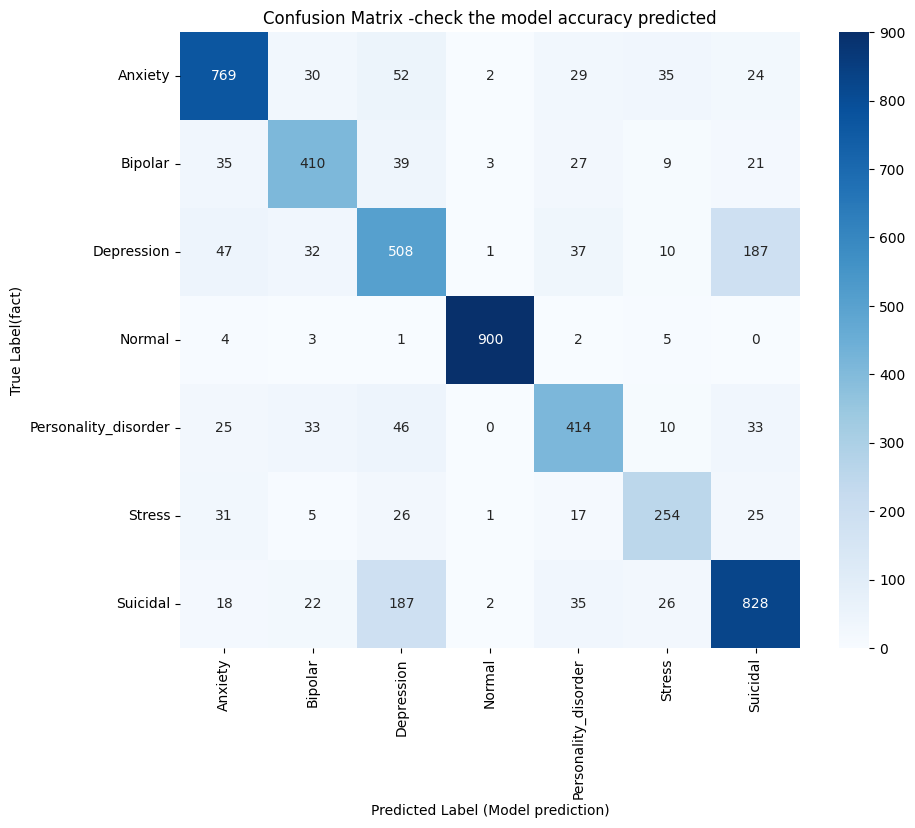

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label (Model prediction)')
plt.ylabel('True Label(fact)')
plt.title('Confusion Matrix -check the model accuracy predicted')
plt.show()


Final Test Accuracy: 78.02%
Final Test Loss: 0.6859
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- Detailed Classification Report ---
                      precision    recall  f1-score   support

             Anxiety       0.85      0.80      0.82       941
             Bipolar       0.75      0.75      0.75       544
          Depression       0.62      0.58      0.60       822
              Normal       0.99      0.98      0.99       915
Personality_disorder       0.74      0.76      0.75       561
              Stress       0.72      0.75      0.74       359
            Suicidal       0.73      0.78      0.75      1118

            accuracy                           0.78      5260
           macro avg       0.77      0.77      0.77      5260
        weighted avg       0.78      0.78      0.78      5260



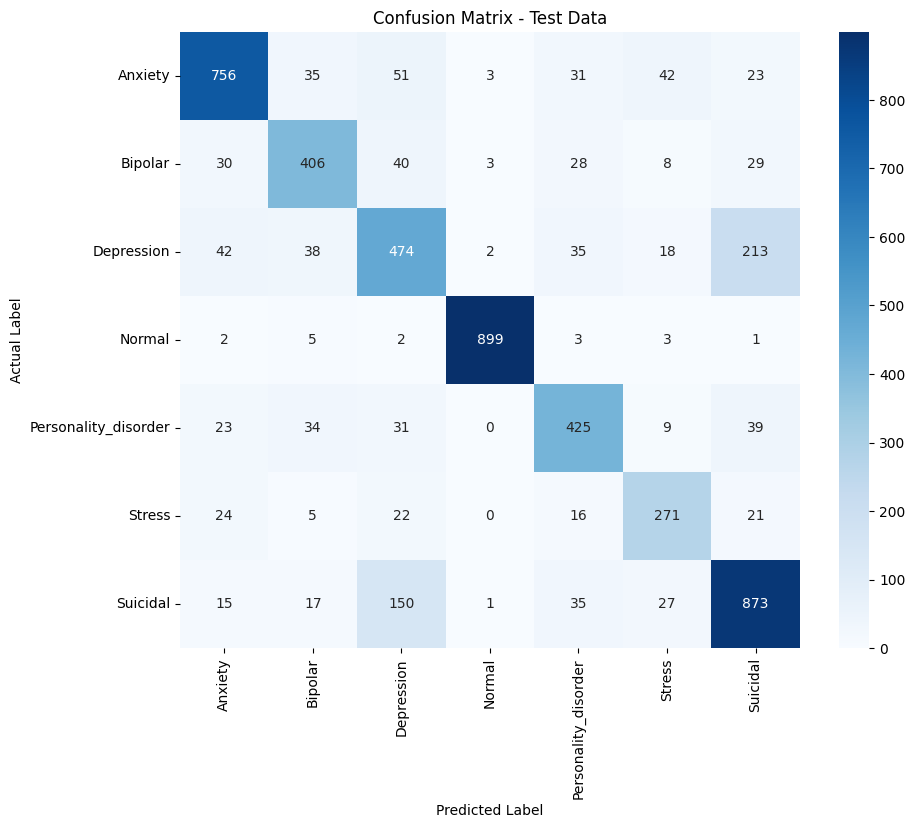

In [26]:

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Test Data')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


In [32]:

model.save('mental_health_model.h5')

print("the model saved already")


the model saved already
